# 演示下streaming模式
这个章节主要演示下这个模式下的一些api用发



In [1]:

from langchain_openai import ChatOpenAI


llm = ChatOpenAI(
    model="glm-4.7",
    api_key="d1de7475090740ebb6c887167a6a8b98.2WUSfYbmgQwYLKF4",
    base_url="https://open.bigmodel.cn/api/paas/v4/",  # 智谱OpenAI兼容地址，末尾斜杠不能丢
)

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


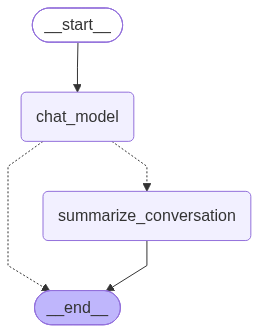

In [5]:
from langgraph.graph import END, START, MessagesState, StateGraph
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display, Image

class State(MessagesState):
    summary: str


def call_model(state: State, config: RunnableConfig) -> State:
    summary = state.get("summary", "")

    if summary:
        system_message = f"summary of conversation earlier:{summary}"
        messages = [SystemMessage(content=system_message)] + state["messages"]
    else:
        messages = state["messages"]

    response = llm.invoke(messages,config)
    return {"messages": response}


def summarize_conversation(state: State):
    summary = state.get("summary", "")

    if summary:
        summary_message = (
            f"this is summary of the conversation to date:{summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
    else:
        summary_message = "Create a summary of the conversation above:"

    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = llm.invoke(messages)

    delete_messages = [RemoveMessage(id=m.id) for m in messages[:-2]]

    return {"messages": delete_messages, "summary": response.content}


def should_continue(state:State):
    messages = state["messages"]
    if len(messages) > 6:
        return "summarize_conversation"

    return END


graph = StateGraph(State)
graph.add_node("summarize_conversation", summarize_conversation)
graph.add_node("chat_model", call_model)

graph.add_edge(START, "chat_model")
graph.add_conditional_edges("chat_model", should_continue, ["summarize_conversation",END])
graph.add_edge("summarize_conversation", END)

memory = MemorySaver()
app = graph.compile(checkpointer=memory)

display(Image(app.get_graph().draw_mermaid_png()))

In [4]:
# stream mode = "updates"
from rich import print


config = {"configurable": {"thread_id": "1"}}

for chunk in app.stream(
    {"messages":[HumanMessage(content="你好,我是Ryan")]},
    config = config,
    stream_mode = 'updates'
):
    print(chunk)

{
    'chat_model': {
        'messages': AIMessage(
            content='你好，Ryan！很高兴认识你。\n\n我是GLM，由Z.ai训练的大语言模型。有什么我能帮你解答的问题或者想
聊的话题吗？无论是工作、学习还是日常生活中的问题，都欢迎随时告诉我。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 748,
                    'prompt_tokens': 62,
                    'total_tokens': 810,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 700,
                        'rejected_prediction_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0
                    }
                },
                'model_provider': 'openai',
                'model_name': 'glm-4.7',
                'system_fingerprint': None,
                'id': '20260824160547111330252af84247',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a032cd-ddee-7a50-9eaa-2cb479cd7e71-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 62,
                'output_tokens': 748,
                'total_tokens': 810,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 700}
            }
        )
    }
}

In [7]:
for chunk in app.stream(
    {"messages": [HumanMessage(content="你好,我是Ryan")]},
    config=config,
    stream_mode="updates",
):
    chunk['chat_model']["messages"].pretty_print()

================================== Ai Message ==================================

你好，Ryan！我是 GLM。很高兴认识你。请问有什么我可以帮你的吗？


In [8]:
# stream_mode = "values"
for event in app.stream({"messages":[HumanMessage("hello, i am ryan")]}, config, stream_mode="values"):
    for m in event['messages']:
        m.pretty_print()

    print("---" * 25)


================================== Ai Message ==================================

你好，Ryan！我已经记住你的名字了。

你是想测试一下我的反应，还是有什么特别想聊的话题还没想好怎么说呢？无论怎样，我都在这里随时准备开始我们的对话！你想聊点什么？
================================ Human Message =================================

你好,我是Ryan
================================== Ai Message ==================================

你好，Ryan！我是 GLM。很高兴认识你。请问有什么我可以帮你的吗？
================================ Human Message =================================

hello, i am ryan


---------------------------------------------------------------------------

================================== Ai Message ==================================

你好，Ryan！我已经记住你的名字了。

你是想测试一下我的反应，还是有什么特别想聊的话题还没想好怎么说呢？无论怎样，我都在这里随时准备开始我们的对话！你想聊点什么？
================================ Human Message =================================

你好,我是Ryan
================================== Ai Message ==================================

你好，Ryan！我是 GLM。很高兴认识你。请问有什么我可以帮你的吗？
================================ Human Message =================================

hello, i am ryan
================================== Ai Message ==================================

Hello Ryan! How can I help you today?


---------------------------------------------------------------------------

In [3]:
async def stream_response(graph, input_message, node_name="chat_model"):
    config = {"configurable": {"thread_id": "5"}}
    async for event in graph.astream_events(
        {"messages": [input_message]}, config, version="v2"
    ):
        if (
            event["event"] == "on_chat_model_stream"
            and event["metadata"].get("langgraph_node") == node_name
        ):
            token = event["data"]["chunk"].content
            if token:
                yield token

In [10]:
# astream_events (token streaming)
async for token in stream_response(app,HumanMessage(content="你知道我的爱好吗")):
    print(token,end='',flush=True)

不，我还不知道您的爱好。

在刚才的对话中，您只告诉我您叫 Ryan，还没有跟我提到过您的爱好。

您愿意跟我分享一下吗？比如您平时喜欢做什么、对什么感兴趣？我可以在我们当前的对话中记住这个信息。